In [1]:
import os
import copy
import time
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.datasets import ImageFolder
from torchvision.models import DenseNet121_Weights

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
class CTDataset(Dataset):
    def __init__(self, image_paths, labels, image_size=256, augment=False, use_clahe=False):
        self.image_paths = image_paths
        self.labels = labels
        self.image_size = image_size
        self.augment = augment
        self.use_clahe = use_clahe

        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

        self.clahe = cv2.createCLAHE(
            clipLimit=2.0,
            tileGridSize=(8, 8)
        )

    def __len__(self):
        return len(self.image_paths)

    def apply_clahe(self, img):
        img_u8 = (img * 255.0).clip(0, 255).astype(np.uint8)
        img_u8 = self.clahe.apply(img_u8)
        return img_u8.astype(np.float32) / 255.0

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        label = self.labels[idx]

        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

        if img is None:
            raise FileNotFoundError(f"Could not read image: {path}")

        if img.ndim == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        img = cv2.resize(
            img,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_AREA
        )

        img = img.astype(np.float32)

        if img.max() > 255:
            img = img / 65535.0
        else:
            img = img / 255.0

        if self.use_clahe:
            img = self.apply_clahe(img)

        if self.augment:
            if np.random.rand() < 0.5:
                img = np.fliplr(img).copy()

            if np.random.rand() < 0.5:
                angle = np.random.uniform(-10, 10)
                M = cv2.getRotationMatrix2D(
                    (self.image_size // 2, self.image_size // 2),
                    angle,
                    1.0
                )
                img = cv2.warpAffine(
                    img,
                    M,
                    (self.image_size, self.image_size),
                    borderMode=cv2.BORDER_REFLECT
                )

            if np.random.rand() < 0.5:
                alpha = np.random.uniform(0.9, 1.1)
                beta = np.random.uniform(-0.05, 0.05)
                img = np.clip(alpha * img + beta, 0, 1)

            if np.random.rand() < 0.3:
                noise = np.random.normal(0, 0.02, img.shape).astype(np.float32)
                img = np.clip(img + noise, 0, 1)

        img = torch.from_numpy(img.astype(np.float32)).unsqueeze(0)
        img = img.repeat(3, 1, 1)

        img = (img - self.mean) / self.std

        label = torch.tensor(label, dtype=torch.long)

        return img, label

In [4]:
train_dir = r"C:\Users\rgzep\Documents\IP data\data_png_wholeslice_lung256_processed\Centre10_split\train"
val_dir   = r"C:\Users\rgzep\Documents\IP data\data_png_wholeslice_lung256_processed\Centre10_split\val"
test_dir  = r"C:\Users\rgzep\Documents\IP data\data_png_wholeslice_lung256_processed\Centre10_split\test"

img_size = 256
batch_size = 24
num_workers = 0

save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

In [5]:
train_base = ImageFolder(train_dir)
val_base = ImageFolder(val_dir)
test_base = ImageFolder(test_dir)

train_paths = [s[0] for s in train_base.samples]
train_labels = [s[1] for s in train_base.samples]

val_paths = [s[0] for s in val_base.samples]
val_labels = [s[1] for s in val_base.samples]

test_paths = [s[0] for s in test_base.samples]
test_labels = [s[1] for s in test_base.samples]

class_names = train_base.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

Classes: ['no_nodule', 'nodule']
Train: 4050
Val: 860
Test: 890


In [6]:
train_data = CTDataset(train_paths, train_labels, image_size=img_size, augment=True)
val_data   = CTDataset(val_paths, val_labels, image_size=img_size, augment=False)
test_data  = CTDataset(test_paths, test_labels, image_size=img_size, augment=False)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=num_workers,  pin_memory=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers,  pin_memory=True)

In [7]:
dropout_rate = 0.5

model = models.densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)

model.classifier = nn.Sequential(
    nn.Dropout(dropout_rate),
    nn.Linear(model.classifier.in_features, num_classes)
)

model = model.to(device)
print(model)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [8]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [9]:
def compute_metrics(y_true, y_pred, y_prob=None):
    metrics = {}
    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["precision"] = precision_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["recall"] = recall_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["f1"] = f1_score(y_true, y_pred, average="macro", zero_division=0)

    if y_prob is not None:
        metrics["auc"] = roc_auc_score(y_true, y_prob[:, 1])
    else:
        metrics["auc"] = np.nan
    return metrics

In [10]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    y_true, y_pred, y_prob = [], [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        probs = torch.softmax(out, dim=1)
        preds = torch.argmax(probs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.detach().cpu().numpy())

    avg_loss = total_loss / len(loader)
    metrics = compute_metrics(y_true, y_pred, np.array(y_prob))
    return avg_loss, metrics

In [11]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item()

            probs = torch.softmax(out, dim=1)
            preds = torch.argmax(probs, dim=1)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(loader)
    y_prob = np.array(y_prob)
    metrics = compute_metrics(y_true, y_pred, y_prob)

    return avg_loss, metrics, y_true, y_pred, y_prob

In [12]:
learning_rate = 1e-3
weight_decay = 1e-4

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=learning_rate,
    weight_decay=weight_decay
)

In [13]:
history = {
    "phase": [],
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_precision": [],
    "val_precision": [],
    "train_recall": [],
    "val_recall": [],
    "train_f1": [],
    "val_f1": [],
    "train_auc": [],
    "val_auc": [],
    "epoch_time_sec": []
}

best_sen = 0
best_wts = copy.deepcopy(model.state_dict())

In [14]:
freeze_epochs = 5

for epoch in range(freeze_epochs):
    start = time.time()

    train_loss, train_metrics = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_metrics, _, _, _ = evaluate(model, val_loader, criterion, device)

    epoch_time = time.time() - start

    history["phase"].append("frozen")
    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_metrics["accuracy"])
    history["val_acc"].append(val_metrics["accuracy"])
    history["train_precision"].append(train_metrics["precision"])
    history["val_precision"].append(val_metrics["precision"])
    history["train_recall"].append(train_metrics["recall"])
    history["val_recall"].append(val_metrics["recall"])
    history["train_f1"].append(train_metrics["f1"])
    history["val_f1"].append(val_metrics["f1"])
    history["train_auc"].append(train_metrics["auc"])
    history["val_auc"].append(val_metrics["auc"])
    history["epoch_time_sec"].append(epoch_time)

    print(
        f"[Frozen] Epoch {epoch+1}/{freeze_epochs} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_metrics['accuracy']:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | Val AUC: {val_metrics['auc']:.4f} | Val Recall: {val_metrics['recall']:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

    if val_metrics["recall"] > best_sen:
        best_sen = val_metrics["recall"]
        best_wts = copy.deepcopy(model.state_dict())

[Frozen] Epoch 1/5 | Train Loss: 0.5224 | Val Loss: 0.3832 | Train Acc: 0.7464 | Val Acc: 0.8337 | Val F1: 0.7513 | Val AUC: 0.8840 | Val Recall: 0.7223 | Time: 24.3s
[Frozen] Epoch 2/5 | Train Loss: 0.4737 | Val Loss: 0.3664 | Train Acc: 0.7795 | Val Acc: 0.8384 | Val F1: 0.7563 | Val AUC: 0.8916 | Val Recall: 0.7254 | Time: 23.9s
[Frozen] Epoch 3/5 | Train Loss: 0.4712 | Val Loss: 0.3642 | Train Acc: 0.7788 | Val Acc: 0.8465 | Val F1: 0.7886 | Val AUC: 0.8974 | Val Recall: 0.7696 | Time: 23.5s
[Frozen] Epoch 4/5 | Train Loss: 0.4707 | Val Loss: 0.3555 | Train Acc: 0.7795 | Val Acc: 0.8349 | Val F1: 0.7593 | Val AUC: 0.9030 | Val Recall: 0.7327 | Time: 23.5s
[Frozen] Epoch 5/5 | Train Loss: 0.4696 | Val Loss: 0.3895 | Train Acc: 0.7736 | Val Acc: 0.8047 | Val F1: 0.6727 | Val AUC: 0.9011 | Val Recall: 0.6500 | Time: 23.4s


In [15]:
model.load_state_dict(best_wts)

for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=weight_decay)

In [16]:
epochs = 10
patience = 5
counter = 0

for epoch in range(epochs):
    start = time.time()

    train_loss, train_metrics = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_metrics, _, _, _ = evaluate(model, val_loader, criterion, device)

    epoch_time = time.time() - start

    history["phase"].append("finetune")
    history["epoch"].append(freeze_epochs + epoch + 1)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_metrics["accuracy"])
    history["val_acc"].append(val_metrics["accuracy"])
    history["train_precision"].append(train_metrics["precision"])
    history["val_precision"].append(val_metrics["precision"])
    history["train_recall"].append(train_metrics["recall"])
    history["val_recall"].append(val_metrics["recall"])
    history["train_f1"].append(train_metrics["f1"])
    history["val_f1"].append(val_metrics["f1"])
    history["train_auc"].append(train_metrics["auc"])
    history["val_auc"].append(val_metrics["auc"])
    history["epoch_time_sec"].append(epoch_time)

    print(
        f"[FineTune] Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_metrics['accuracy']:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | Val AUC: {val_metrics['auc']:.4f} | Val Recall: {val_metrics['recall']:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

    if val_metrics["recall"] > best_sen:
        best_sen = val_metrics["recall"]
        best_wts = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping")
        break

[FineTune] Epoch 1/10 | Train Loss: 0.4200 | Val Loss: 0.3439 | Train Acc: 0.7995 | Val Acc: 0.8500 | Val F1: 0.7984 | Val AUC: 0.8981 | Val Recall: 0.7844 | Time: 54.8s
[FineTune] Epoch 2/10 | Train Loss: 0.3723 | Val Loss: 0.3219 | Train Acc: 0.8296 | Val Acc: 0.8581 | Val F1: 0.8137 | Val AUC: 0.9116 | Val Recall: 0.8052 | Time: 44.6s
[FineTune] Epoch 3/10 | Train Loss: 0.3502 | Val Loss: 0.3284 | Train Acc: 0.8417 | Val Acc: 0.8547 | Val F1: 0.8111 | Val AUC: 0.9063 | Val Recall: 0.8056 | Time: 44.2s
[FineTune] Epoch 4/10 | Train Loss: 0.3156 | Val Loss: 0.3286 | Train Acc: 0.8593 | Val Acc: 0.8535 | Val F1: 0.8098 | Val AUC: 0.9077 | Val Recall: 0.8048 | Time: 44.5s
[FineTune] Epoch 5/10 | Train Loss: 0.2699 | Val Loss: 0.3427 | Train Acc: 0.8795 | Val Acc: 0.8384 | Val F1: 0.7855 | Val AUC: 0.8981 | Val Recall: 0.7751 | Time: 44.7s
[FineTune] Epoch 6/10 | Train Loss: 0.2466 | Val Loss: 0.3717 | Train Acc: 0.8921 | Val Acc: 0.8326 | Val F1: 0.7857 | Val AUC: 0.8952 | Val Recall: 0

In [17]:
model.load_state_dict(best_wts)
print("Best Validation Sensitivity:", best_sen)

Best Validation Sensitivity: 0.8198757763975155


In [18]:
test_loss, test_metrics, y_true, y_pred, y_prob = evaluate(model, test_loader, criterion, device)

print("\nTest Results")
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_metrics["accuracy"], 4))
print("Test Precision:", round(test_metrics["precision"], 4))
print("Test Recall:", round(test_metrics["recall"], 4))
print("Test F1:", round(test_metrics["f1"], 4))
print("Test AUC:", round(test_metrics["auc"], 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


Test Results
Test Loss: 0.6659
Test Accuracy: 0.7719
Test Precision: 0.7196
Test Recall: 0.7293
Test F1: 0.7239
Test AUC: 0.8044

Confusion Matrix:
[[158  92]
 [111 529]]

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.59      0.63      0.61       250
      nodule       0.85      0.83      0.84       640

    accuracy                           0.77       890
   macro avg       0.72      0.73      0.72       890
weighted avg       0.78      0.77      0.77       890



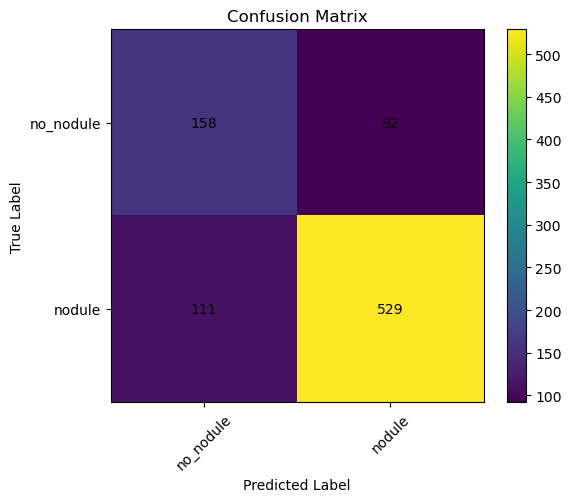

In [19]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

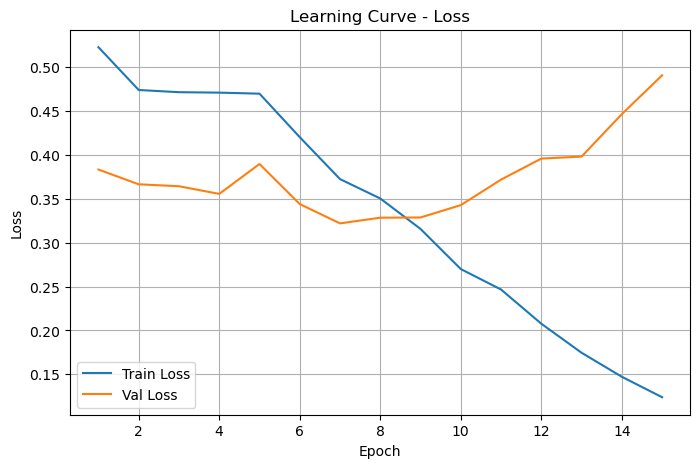

In [20]:
epochs_ran = range(1, len(history["epoch"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_loss"], label="Train Loss")
plt.plot(epochs_ran, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve - Loss")
plt.legend()
plt.grid(True)
plt.show()

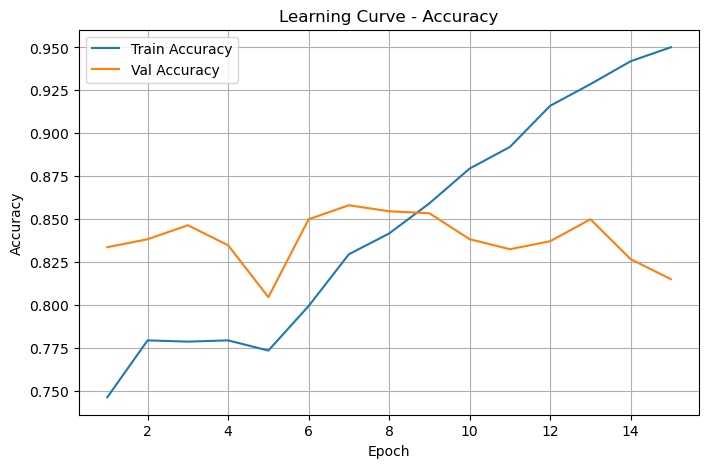

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_ran, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Accuracy")
plt.legend()
plt.grid(True)
plt.show()

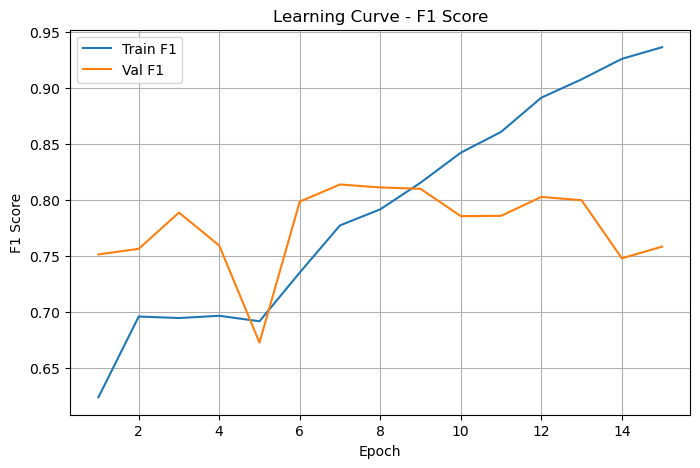

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_f1"], label="Train F1")
plt.plot(epochs_ran, history["val_f1"], label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Learning Curve - F1 Score")
plt.legend()
plt.grid(True)
plt.show()

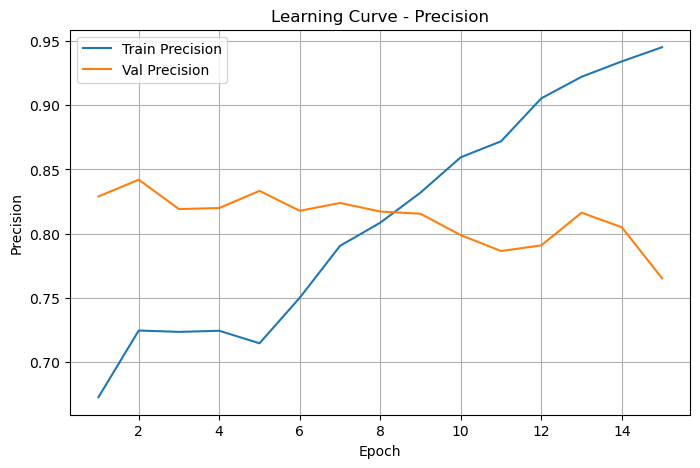

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_precision"], label="Train Precision")
plt.plot(epochs_ran, history["val_precision"], label="Val Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Learning Curve - Precision")
plt.legend()
plt.grid(True)
plt.show()

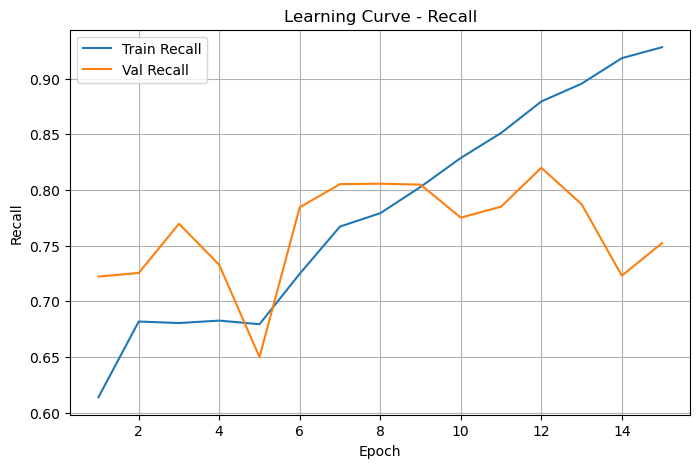

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_recall"], label="Train Recall")
plt.plot(epochs_ran, history["val_recall"], label="Val Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Learning Curve - Recall")
plt.legend()
plt.grid(True)
plt.show()

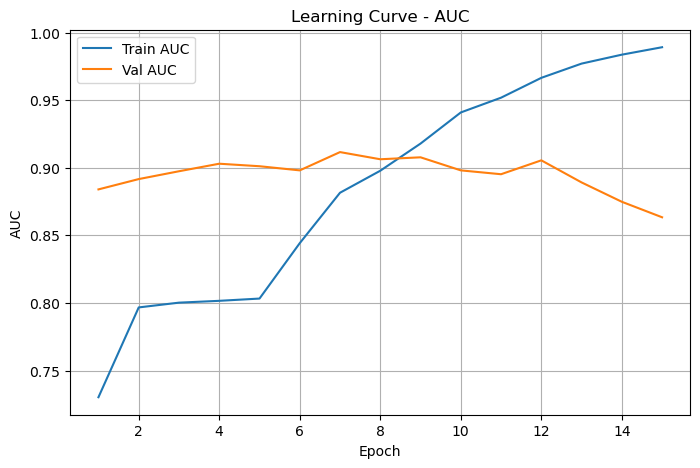

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_auc"], label="Train AUC")
plt.plot(epochs_ran, history["val_auc"], label="Val AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Learning Curve - AUC")
plt.legend()
plt.grid(True)
plt.show()

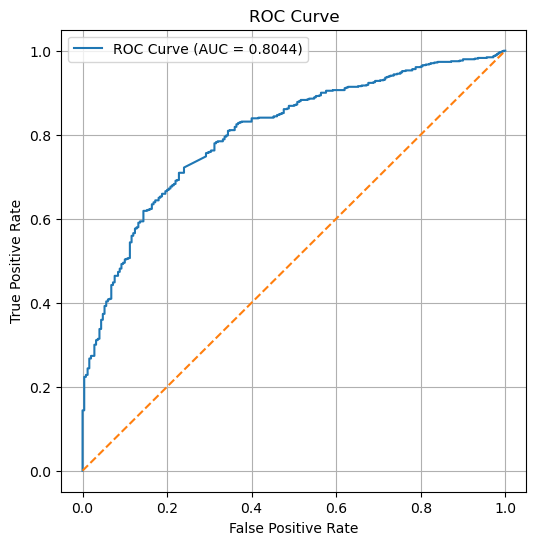

In [26]:
fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {test_metrics['auc']:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
torch.save(model.state_dict(), "saved_models/densenet121_best_sen.pth")
print("Model saved")

Model saved


In [28]:
loaded_model = models.densenet121(weights=None)

loaded_model.classifier = nn.Sequential(
    nn.Dropout(dropout_rate),
    nn.Linear(loaded_model.classifier.in_features, num_classes)
)

loaded_model.load_state_dict(torch.load("saved_models/densenet121_best_sen.pth", map_location=device))
loaded_model = loaded_model.to(device)
loaded_model.eval()
print("Model loaded")

C:\Users\rgzep\AppData\Local\Temp\ipykernel_13736\477093306.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load("saved_models/densene

Model loaded
